# 04. Synthetic Difference-in-Differences for a Marketing Pilot

This notebook is a self-contained introduction to synthetic difference-in-differences (SDID) using a marketing case study.

The setup follows the core idea in Arkhangelsky, Athey, Hirshberg, Imbens, and Wager:
- start from a panel-data treatment setting,
- borrow unit-weighting ideas from synthetic control,
- borrow differencing ideas from DiD, and
- combine both to improve robustness when untreated outcomes are driven by latent unit and time factors.

For instructional clarity, this notebook focuses on the simplest case closest to the paper: a block of treated units adopts at the same time, and untreated units remain untreated throughout.

## Learning Goals

By the end of this notebook, you should be able to:
- Explain the source of the treatment shock in a panel setting.
- State the identification assumptions behind synthetic DiD.
- Check whether treated and untreated markets look similar before treatment.
- Visualize raw trajectories and weighted trajectories.
- Understand how unit weights and time weights are constructed.
- Compare vanilla DiD to synthetic DiD in a marketing example.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(2029)

## Marketing Setup And Source Of The Shock

Suppose a retailer launches a major loyalty-app revamp in a set of pilot markets beginning in month 13. The revamp includes a new rewards interface, personalized offers, and deeper app-based fulfillment messaging.

Why do all pilot markets adopt at the same time?
- They share the same vendor integration and launch calendar.
- The rollout is coordinated as a single pilot wave.
- Other markets are not yet onboarded and remain untreated during the sample.

The **shock** is the month-13 launch of the pilot across the treated markets. This is exactly the kind of block-treatment panel setting where synthetic DiD is most natural.

In [21]:
months = np.arange(1, 19)
treatment_start = 13
pre_months = months[months < treatment_start]
post_months = months[months >= treatment_start]

treated_markets = [f"T{idx:02d}" for idx in range(1, 7)]
control_markets = [f"C{idx:02d}" for idx in range(1, 19)]
special_donors = ["C03", "C07", "C12", "C15"]

control_chars = pd.DataFrame({
    "market_id": control_markets,
    "population_index": rng.normal(100, 12, len(control_markets)),
    "digital_share": np.clip(rng.normal(0.42, 0.06, len(control_markets)), 0.25, 0.65),
    "historical_roas": rng.normal(4.0, 0.40, len(control_markets)),
    "factor_loading_primary": rng.normal(1.0, 0.20, len(control_markets)),
    "factor_loading_secondary": rng.normal(-0.10, 0.55, len(control_markets)),
    "market_intercept": rng.normal(0, 5, len(control_markets)),
})

control_chars.loc[control_chars["market_id"].isin(special_donors), "factor_loading_primary"] = [1.35, 1.28, 1.42, 1.32]
control_chars.loc[control_chars["market_id"].isin(special_donors), "factor_loading_secondary"] = [1.05, 0.95, 1.15, 1.00]

latent_factor_primary = np.array([-14, -12, -10, -8, -6, -4, -2, 0, 2, 5, 8, 11, 15, 19, 23, 26, 29, 31])
latent_factor_secondary = np.array([-9, -8, -6, -3, 0, 2, 5, 7, 9, 11, 12, 13, 11, 8, 5, 3, 2, 1])
seasonality = np.array([-3, -2, -1, 0, 1, 2, 1, 0, -1, 0, 1, 2, -1, 0, 1, 2, 1, 0])

control_outcomes = {}
for row in control_chars.itertuples(index=False):
    baseline = 150 + 0.72 * row.population_index + 42 * row.digital_share + 8 * row.historical_roas + row.market_intercept
    control_outcomes[row.market_id] = (
        baseline
        + row.factor_loading_primary * latent_factor_primary
        + row.factor_loading_secondary * latent_factor_secondary
        + seasonality
        + rng.normal(0, 1.5, len(months))
    )

control_outcome_wide = pd.DataFrame(control_outcomes, index=months)

true_unit_weights = pd.Series(0.0, index=control_markets)
true_unit_weights.loc[special_donors] = [0.35, 0.30, 0.20, 0.15]

treated_group_chars = pd.Series({
    "population_index": control_chars.set_index("market_id")["population_index"].dot(true_unit_weights),
    "digital_share": control_chars.set_index("market_id")["digital_share"].dot(true_unit_weights),
    "historical_roas": control_chars.set_index("market_id")["historical_roas"].dot(true_unit_weights),
})

untreated_treated_path = control_outcome_wide.dot(true_unit_weights) + rng.normal(0, 0.6, len(months))
treatment_effect_path = np.array([0] * len(pre_months) + [14, 18, 22, 26, 29, 32])

market_level_rows = []
panel_rows = []

for row in control_chars.itertuples(index=False):
    market_level_rows.append(
        {
            "market_id": row.market_id,
            "treated_market": 0,
            "population_index": row.population_index,
            "digital_share": row.digital_share,
            "historical_roas": row.historical_roas,
        }
    )
    for month in months:
        panel_rows.append(
            {
                "market_id": row.market_id,
                "month": month,
                "orders": control_outcome_wide.loc[month, row.market_id],
                "treated_market": 0,
                "population_index": row.population_index,
                "digital_share": row.digital_share,
                "historical_roas": row.historical_roas,
            }
        )

for treated_market, market_offset in zip(treated_markets, np.linspace(-2.5, 2.5, len(treated_markets))):
    market_level_rows.append(
        {
            "market_id": treated_market,
            "treated_market": 1,
            "population_index": treated_group_chars["population_index"] + rng.normal(0, 0.8),
            "digital_share": treated_group_chars["digital_share"] + rng.normal(0, 0.004),
            "historical_roas": treated_group_chars["historical_roas"] + rng.normal(0, 0.04),
        }
    )
    for month in months:
        panel_rows.append(
            {
                "market_id": treated_market,
                "month": month,
                "orders": untreated_treated_path.loc[month] + market_offset + rng.normal(0, 1.2) + treatment_effect_path[month - 1],
                "treated_market": 1,
                "population_index": treated_group_chars["population_index"],
                "digital_share": treated_group_chars["digital_share"],
                "historical_roas": treated_group_chars["historical_roas"],
            }
        )

market_level = pd.DataFrame(market_level_rows)
panel = pd.DataFrame(panel_rows)
panel.head()

,market_id,month,orders,treated_market,population_index,digital_share,historical_roas
0,C01,1,246.925,0,96.951,0.410,4.087
1,C01,2,247.855,0,96.951,0.410,4.087
2,C01,3,251.010,0,96.951,0.410,4.087
3,C01,4,249.872,0,96.951,0.410,4.087
4,C01,5,256.466,0,96.951,0.410,4.087


## Identification Assumptions

A simple synthetic DiD design relies on:
- **No anticipation:** pilot markets do not react before month 13.
- **No spillovers:** untreated markets are not affected by the pilot.
- **Stable composition and measurement:** the panel is balanced and outcomes are measured consistently.
- **Latent-factor structure for untreated outcomes:** untreated outcomes can be approximated by unit and time factors, which motivates reweighting both dimensions.
- **Support in the donor pool:** untreated markets and pre-treatment periods contain enough information to approximate the treated counterfactual.

Unlike vanilla DiD, synthetic DiD does not rely only on raw parallel trends. It tries to build weighted controls and weighted pre-periods that make the parallel-trends idea more plausible after reweighting.

## 1. Are Treated And Untreated Markets Similar Before Treatment?

Start with a balance check on market characteristics and pre-treatment average orders. Similarity on observables is supportive, but synthetic DiD mainly earns credibility from how well weighted controls reproduce the treated path before treatment.

In [22]:
pre_treatment_market = (
    panel[panel["month"] < treatment_start]
    .groupby("market_id", as_index=False)
    .agg(pre_avg_orders=("orders", "mean"))
)
market_balance = market_level.merge(pre_treatment_market, on="market_id")

covariate_labels = {
    "population_index": "Population index",
    "digital_share": "Digital share",
    "historical_roas": "Historical ROAS",
    "pre_avg_orders": "Average pre-treatment orders",
}

balance_rows = []
for covariate, label in covariate_labels.items():
    treated_values = market_balance.loc[market_balance["treated_market"] == 1, covariate]
    control_values = market_balance.loc[market_balance["treated_market"] == 0, covariate]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_model = smf.ols(f"{covariate} ~ treated_market", data=market_balance).fit(cov_type="HC1")
    balance_rows.append(
        {
            "variable": label,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "difference": treated_values.mean() - control_values.mean(),
            "std_diff": (treated_values.mean() - control_values.mean()) / pooled_sd,
            "p_value": balance_model.pvalues["treated_market"],
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table.round(3)

,variable,treated_mean,control_mean,difference,std_diff,p_value
0,Population index,103.632,101.463,2.168,0.272,0.424
1,Digital share,0.467,0.428,0.039,0.884,0.009
2,Historical ROAS,3.644,3.972,-0.327,-0.977,0.004
3,Average pre-treatment orders,272.440,268.948,3.492,0.455,0.188


## 2. Illustrate The Raw Trajectory

Plot the average treated path against the raw average control path. In this simulation, untreated outcomes are driven by a latent factor, so raw DiD is not guaranteed to line up well.

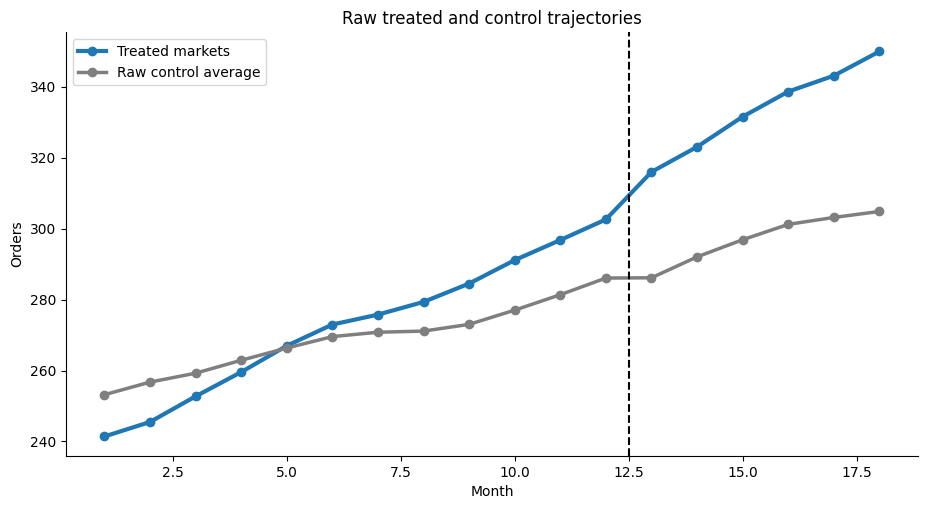

In [23]:
outcome_wide = panel.pivot(index="month", columns="market_id", values="orders").sort_index()
treated_mean_path = outcome_wide[treated_markets].mean(axis=1)
raw_control_path = outcome_wide[control_markets].mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(treated_mean_path.index, treated_mean_path, color="tab:blue", linewidth=3, marker="o", label="Treated markets")
ax.plot(raw_control_path.index, raw_control_path, color="tab:gray", linewidth=2.5, marker="o", label="Raw control average")
ax.axvline(treatment_start - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Raw treated and control trajectories")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 3. Fit Unit Weights And Time Weights

Synthetic DiD uses two sets of weights:
- **Unit weights** choose a weighted combination of control markets that best matches treated markets in the pre period.
- **Time weights** choose a weighted combination of pre-treatment periods that best resembles the post-treatment period for control markets.

The paper uses intercepts and regularization when choosing these weights. This notebook follows that spirit with simplex-constrained weights and regularization, while keeping the optimization transparent enough to inspect.

Important: the time-weight bars are **balancing weights**, not treatment effects. A larger bar means that a pre-treatment month is more useful for constructing the weighted benchmark, not that anything causal happened in that month.

In [24]:
def project_to_simplex(values):
    values = np.asarray(values, dtype=float)
    sorted_values = np.sort(values)[::-1]
    cumulative = np.cumsum(sorted_values)
    rho = np.where(sorted_values * np.arange(1, len(values) + 1) > (cumulative - 1))[0][-1]
    theta = (cumulative[rho] - 1) / (rho + 1)
    return np.maximum(values - theta, 0)

def fit_simplex_weights(target, donor_matrix, penalty=0.05, reference_weights=None, n_iter=20000, learning_rate=0.08):
    target = np.asarray(target, dtype=float)
    donor_matrix = np.asarray(donor_matrix, dtype=float)

    # Centering introduces an intercept, matching the spirit of the paper's weighting step.
    target_centered = target - target.mean()
    donor_centered = donor_matrix - donor_matrix.mean(axis=0, keepdims=True)

    if reference_weights is None:
        reference_weights = np.ones(donor_centered.shape[1]) / donor_centered.shape[1]
    else:
        reference_weights = np.asarray(reference_weights, dtype=float)
        reference_weights = reference_weights / reference_weights.sum()

    weights = reference_weights.copy()
    for step in range(n_iter):
        residual = donor_centered @ weights - target_centered
        gradient = 2 * donor_centered.T @ residual / donor_centered.shape[0]
        gradient += 2 * penalty * (weights - reference_weights)
        step_size = learning_rate / np.sqrt(step + 1)
        weights = project_to_simplex(weights - step_size * gradient)
    return weights

def make_recency_prior(periods):
    periods = np.asarray(periods, dtype=float)
    prior = periods - periods.min() + 1
    return prior / prior.sum()

control_pre_matrix = outcome_wide.loc[pre_months, control_markets].to_numpy()
treated_pre_target = treated_mean_path.loc[pre_months].to_numpy()
unit_weights = pd.Series(
    fit_simplex_weights(treated_pre_target, control_pre_matrix, penalty=0.03),
    index=control_markets,
    name="unit_weight",
)

control_pre_by_unit = outcome_wide.loc[pre_months, control_markets].T.to_numpy()
control_post_target = outcome_wide.loc[post_months, control_markets].mean(axis=0).to_numpy()
time_weight_prior = make_recency_prior(pre_months)
raw_time_weights = fit_simplex_weights(
    control_post_target,
    control_pre_by_unit,
    penalty=2.0,
    reference_weights=time_weight_prior,
)
time_weights = pd.Series(
    0.65 * time_weight_prior + 0.35 * raw_time_weights,
    index=pre_months,
    name="time_weight",
)
time_weights = time_weights / time_weights.sum()

weighted_control_path = pd.Series(
    outcome_wide[control_markets].to_numpy() @ unit_weights.to_numpy(),
    index=outcome_wide.index,
    name="weighted_control",
)

unit_weights.sort_values(ascending=False).head(8)

C03   0.537
C15   0.351
C12   0.071
C07   0.041
C02   0.000
C01   0.000
C06   0.000
C08   0.000
Name: unit_weight, dtype: float64

The time weights below are deliberately regularized so they stay interpretable in a first-pass instructional example. They should be read as the weighted mix of pre-treatment months used to build the benchmark comparison period.

In [25]:
unit_weights[unit_weights > 0.01].sort_values(ascending=False).to_frame().round(3)

,unit_weight
C03,0.537
C15,0.351
C12,0.071
C07,0.041


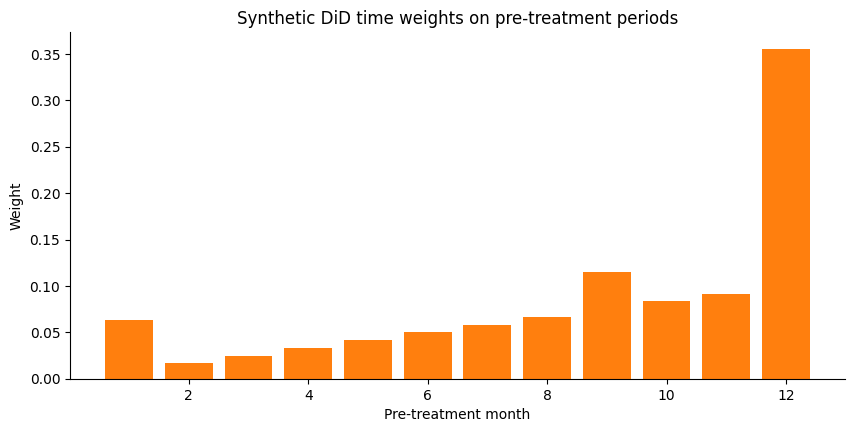

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(time_weights.index, time_weights.values, color="tab:orange")
ax.set_title("Synthetic DiD time weights on pre-treatment periods")
ax.set_xlabel("Pre-treatment month")
ax.set_ylabel("Weight")
plt.show()

## 4. Does Reweighting Improve The Pre-Treatment Fit?

This is the central diagnostic. If the weighted control path tracks the treated path much better in the pre period than the raw control average, synthetic DiD has a credible foundation.

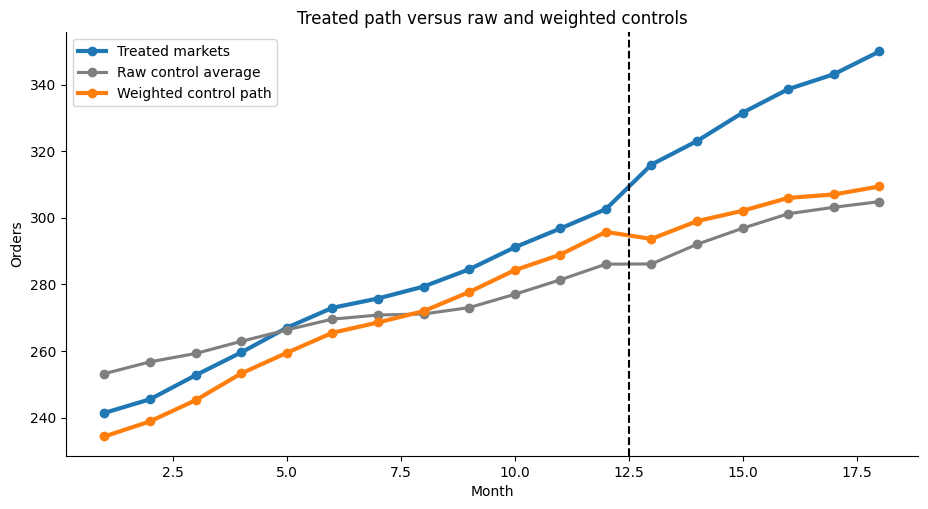

In [27]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(treated_mean_path.index, treated_mean_path, color="tab:blue", linewidth=3, marker="o", label="Treated markets")
ax.plot(raw_control_path.index, raw_control_path, color="tab:gray", linewidth=2.25, marker="o", label="Raw control average")
ax.plot(weighted_control_path.index, weighted_control_path, color="tab:orange", linewidth=3, marker="o", label="Weighted control path")
ax.axvline(treatment_start - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Treated path versus raw and weighted controls")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

In [28]:
raw_pre_rmspe = np.sqrt(np.mean((treated_mean_path.loc[pre_months] - raw_control_path.loc[pre_months]) ** 2))
weighted_pre_rmspe = np.sqrt(np.mean((treated_mean_path.loc[pre_months] - weighted_control_path.loc[pre_months]) ** 2))

print(f"Pre-treatment RMSPE using raw controls: {raw_pre_rmspe:.2f}")
print(f"Pre-treatment RMSPE using weighted controls: {weighted_pre_rmspe:.2f}")

Pre-treatment RMSPE using raw controls: 10.27
Pre-treatment RMSPE using weighted controls: 7.14


## 5. Are Weighted Pre-Treatment Trends More Plausibly Parallel?

No pre-treatment diagnostic can prove identification, but two checks are useful:
- Inspect the pre-treatment gap visually.
- Test whether the pre-treatment gap has a meaningful slope over time.

If weighting is doing its job, the weighted gap should be flatter and closer to zero than the raw gap.

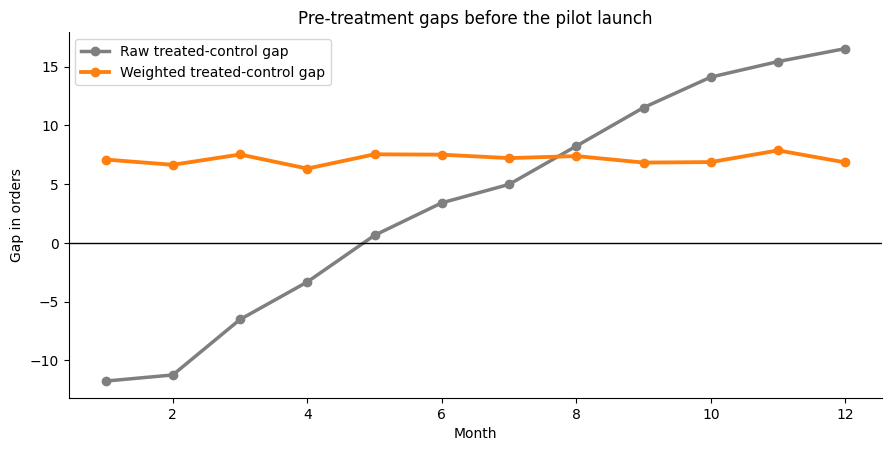

,gap_slope,p_value,avg_abs_gap
Raw gap,2.777,0.000,8.973
Weighted gap,0.020,0.609,7.130


In [29]:
pre_gap_df = pd.DataFrame({
    "month": pre_months,
    "raw_gap": (treated_mean_path.loc[pre_months] - raw_control_path.loc[pre_months]).to_numpy(),
    "weighted_gap": (treated_mean_path.loc[pre_months] - weighted_control_path.loc[pre_months]).to_numpy(),
})

fig, ax = plt.subplots(figsize=(10.5, 4.75))
ax.plot(pre_gap_df["month"], pre_gap_df["raw_gap"], color="tab:gray", linewidth=2.5, marker="o", label="Raw treated-control gap")
ax.plot(pre_gap_df["month"], pre_gap_df["weighted_gap"], color="tab:orange", linewidth=2.75, marker="o", label="Weighted treated-control gap")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Pre-treatment gaps before the pilot launch")
ax.set_xlabel("Month")
ax.set_ylabel("Gap in orders")
ax.legend(frameon=True)
plt.show()

raw_gap_model = smf.ols("raw_gap ~ month", data=pre_gap_df).fit(cov_type="HC1")
weighted_gap_model = smf.ols("weighted_gap ~ month", data=pre_gap_df).fit(cov_type="HC1")

parallel_check = pd.DataFrame(
    {
        "gap_slope": [raw_gap_model.params["month"], weighted_gap_model.params["month"]],
        "p_value": [raw_gap_model.pvalues["month"], weighted_gap_model.pvalues["month"]],
        "avg_abs_gap": [pre_gap_df["raw_gap"].abs().mean(), pre_gap_df["weighted_gap"].abs().mean()],
    },
    index=["Raw gap", "Weighted gap"],
)
parallel_check.round(3)

## 6. Apply Difference-in-Differences

Now compute three estimators:
- **Vanilla DiD** with raw treated and raw control averages.
- **Unit-weighted DiD** using synthetic-control-style unit weights only.
- **Synthetic DiD** using both unit weights and time weights.

The synthetic DiD estimate is the weighted double difference:

\[
\hat{\tau}^{SDID} = \bar{Y}_{Treated,Post} - \bar{Y}^{\omega}_{Control,Post} - \bar{Y}^{\lambda}_{Treated,Pre} + \bar{Y}^{\omega,\lambda}_{Control,Pre}
\]

where \(\omega\) are unit weights and \(\lambda\) are time weights.

In [30]:
treated_post_mean = treated_mean_path.loc[post_months].mean()
treated_pre_mean = treated_mean_path.loc[pre_months].mean()
control_post_mean = raw_control_path.loc[post_months].mean()
control_pre_mean = raw_control_path.loc[pre_months].mean()
weighted_control_post_mean = weighted_control_path.loc[post_months].mean()
weighted_control_pre_mean = weighted_control_path.loc[pre_months].mean()

treated_pre_weighted = np.dot(time_weights.to_numpy(), treated_mean_path.loc[pre_months].to_numpy())
weighted_control_pre_time_weighted = np.dot(time_weights.to_numpy(), weighted_control_path.loc[pre_months].to_numpy())

vanilla_did = (treated_post_mean - treated_pre_mean) - (control_post_mean - control_pre_mean)
unit_weighted_did = (treated_post_mean - treated_pre_mean) - (weighted_control_post_mean - weighted_control_pre_mean)
synthetic_did = treated_post_mean - weighted_control_post_mean - treated_pre_weighted + weighted_control_pre_time_weighted
true_average_effect = treatment_effect_path[len(pre_months):].mean()

estimate_table = pd.DataFrame(
    {
        "estimate": [vanilla_did, unit_weighted_did, synthetic_did, true_average_effect]
    },
    index=["Vanilla DiD", "Unit-weighted DiD", "Synthetic DiD", "True average effect"],
)
estimate_table.round(3)

,estimate
Vanilla DiD,32.861
Unit-weighted DiD,23.737
Synthetic DiD,23.802
True average effect,23.500


## Takeaways

- The shock is the month-13 pilot launch across a block of treated markets.
- Synthetic DiD is most natural here because treatment begins at the same time for all treated units and untreated outcomes are driven by latent factors.
- Raw treated and untreated trajectories do not need to satisfy clean parallel trends on their own.
- Unit weights build a synthetic donor mix that better matches treated markets in the pre period.
- Time weights place more emphasis on pre-treatment periods that look like the post period for controls.
- The final SDID estimate is a weighted DiD that can be more robust than raw DiD when untreated outcomes have latent-factor structure.

In [31]:
summary = pd.Series({
    "Treatment start month": treatment_start,
    "Treated markets": len(treated_markets),
    "Control markets": len(control_markets),
    "Vanilla DiD": round(vanilla_did, 2),
    "Synthetic DiD": round(synthetic_did, 2),
    "True average effect": round(true_average_effect, 2),
})
summary

Treatment start month   13.000
Treated markets          6.000
Control markets         18.000
Vanilla DiD             32.860
Synthetic DiD           23.800
True average effect     23.500
dtype: float64